<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/10_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Clustering Techniques

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 10 membahas teknik-teknik **unsupervised learning** melalui clustering. Berbeda dari semua chapter sebelumnya yang menggunakan supervised learning (data memiliki label target), clustering bekerja pada data yang tidak memiliki label. Tujuannya bukan memprediksi output, melainkan **menemukan struktur tersembunyi** dalam data.

Analogi dunia nyata: bayangkan sebuah bisnis retail ingin memahami segmen pelanggannya. Mereka tidak punya label "Pelanggan Tipe A" atau "Pelanggan Tipe B". Dengan clustering, mereka dapat menemukan subkelompok ini secara otomatis berdasarkan perilaku pembelian, frekuensi kunjungan, dan kategori produk yang dibeli, lalu menyesuaikan strategi pemasaran untuk masing-masing segmen.

### Topik yang Dibahas:
1. Pengantar clustering dan tiga kategori algoritma
2. K-Means Clustering (centroid-based) dan Elbow Method
3. Hierarchical Clustering (Agglomerative) dan Dendrogram
4. DBSCAN (density-based) dan k-distance plot
5. Cluster evaluation metrics (Silhouette, Davies-Bouldin, ARI)
6. Panduan memilih algoritma clustering yang tepat
7. Teknik lanjutan: Spectral Clustering dan Gaussian Mixture Models (GMM)

## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


## 1. Pengantar Clustering

### Penjelasan Teori

**Clustering** adalah teknik unsupervised learning yang mengelompokkan titik-titik data yang serupa ke dalam kelompok (cluster) berdasarkan struktur intrinsik data, tanpa menggunakan label atau target yang telah ditentukan sebelumnya.

**Mengapa clustering penting:**
- **Eksplorasi data:** Memahami struktur dan pola tersembunyi dalam dataset.
- **Segmentasi:** Membagi pelanggan, dokumen, atau gambar ke dalam kelompok yang bermakna.
- **Preprocessing:** Hasil clustering dapat digunakan sebagai fitur untuk model supervised learning.
- **Deteksi anomali:** Titik yang tidak masuk ke cluster mana pun kemungkinan adalah outlier.
- **Kompresi data:** Mewakili cluster dengan centroid-nya saja untuk mengurangi data.

**Tiga kategori utama algoritma clustering:**

| Kategori | Cara Kerja | Contoh Algoritma |
|----------|-----------|-----------------|
| **Centroid-based** | Membentuk cluster di sekitar titik pusat (centroid) | K-Means |
| **Connectivity-based** | Membangun cluster berdasarkan hierarki kedekatan | Agglomerative Clustering |
| **Density-based** | Mendeteksi cluster berdasarkan kepadatan titik data | DBSCAN |

> **Catatan penting:** Clustering adalah lebih banyak seni daripada sains. Tidak ada jawaban "benar" yang absolut. Hasil terbaik bergantung pada pemahaman domain, pemilihan algoritma yang tepat, dan evaluasi yang cermat.

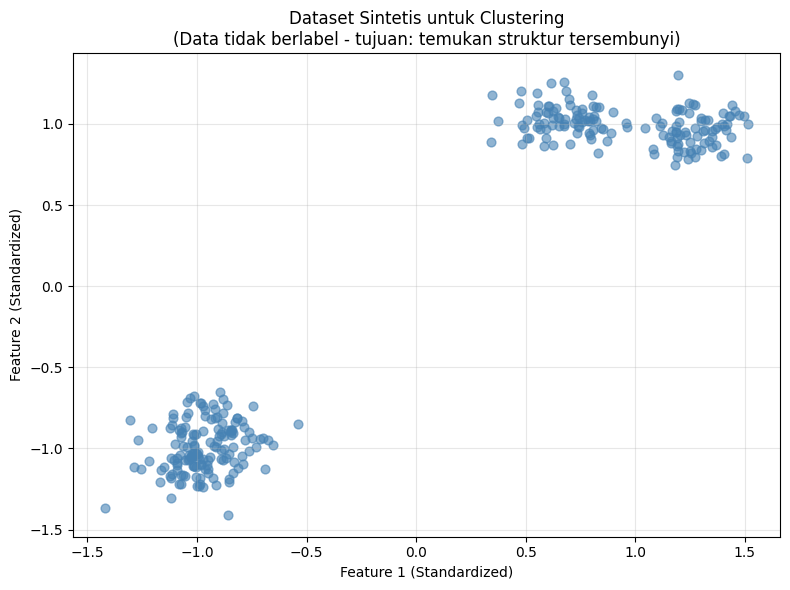

Shape dataset: (300, 2)
Tugas: temukan cluster yang ada tanpa menggunakan label [0 1 2 3]


In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Buat dataset sintetis untuk demonstrasi clustering
X_blob, y_true_blob = make_blobs(
    n_samples=300, centers=4,
    cluster_std=0.60, random_state=2024
)
X_blob = StandardScaler().fit_transform(X_blob)

# Visualisasi data mentah (tanpa label)
plt.figure(figsize=(8, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], s=40, alpha=0.6, color='steelblue')
plt.title('Dataset Sintetis untuk Clustering\n(Data tidak berlabel - tujuan: temukan struktur tersembunyi)')
plt.xlabel('Feature 1 (Standardized)')
plt.ylabel('Feature 2 (Standardized)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Shape dataset: {X_blob.shape}")
print(f"Tugas: temukan cluster yang ada tanpa menggunakan label {np.unique(y_true_blob)}")

## 2. K-Means Clustering

### Penjelasan Teori

**K-Means** adalah algoritma clustering centroid-based yang paling populer. Algoritma ini mempartisi data menjadi K cluster yang tidak tumpang tindih, di mana setiap titik data hanya milik satu cluster.

**Langkah-langkah iterasi K-Means:**
1. **Inisialisasi:** Pilih K centroid secara acak dari data (atau menggunakan K-Means++ untuk inisialisasi yang lebih cerdas).
2. **Assignment Step:** Setiap titik data ditetapkan ke centroid terdekat berdasarkan jarak Euclidean.
3. **Update Step:** Setiap centroid dipindahkan ke rata-rata semua titik yang ditugaskan kepadanya.
4. **Konvergensi:** Ulangi langkah 2-3 hingga centroid tidak berpindah signifikan atau jumlah iterasi maksimum tercapai.

**Fungsi objektif K-Means** adalah meminimalkan **inertia** (within-cluster sum of squares):
```
Inertia = sum_i sum_{x in C_i} ||x - mu_i||^2
```
di mana `mu_i` adalah centroid cluster `C_i`.

**Kekuatan K-Means:**
- Efisien dan skalabel untuk dataset besar.
- Mudah diimplementasikan dan diinterpretasikan.

**Kelemahan K-Means:**
- Memerlukan K (jumlah cluster) sebagai input.
- Sensitif terhadap outlier (karena menggunakan mean).
- Hanya bekerja baik untuk cluster yang berbentuk bola (convex, isotropic).
- Hasil dapat bervariasi tergantung inisialisasi (diatasi dengan K-Means++).

**Menentukan K optimal - Elbow Method:** Plot inertia terhadap berbagai nilai K dan cari "siku" di mana penambahan K tidak lagi memberikan pengurangan inertia yang signifikan.

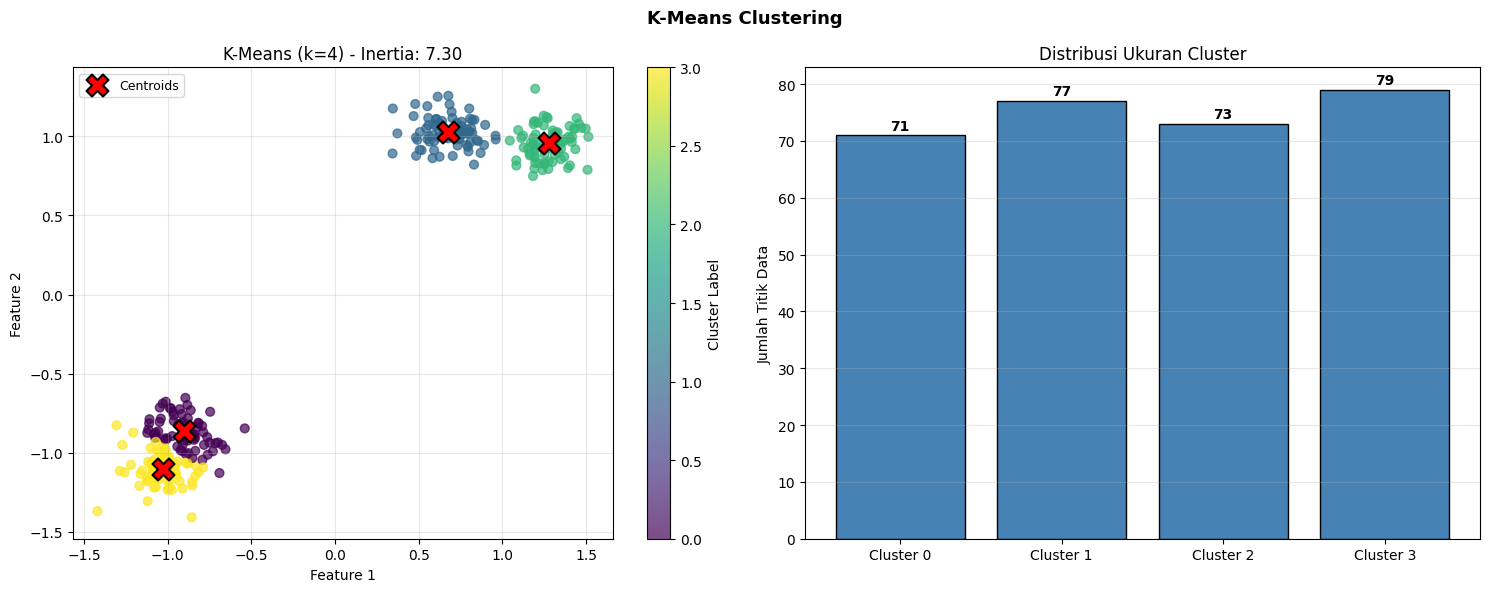

In [3]:
from sklearn.cluster import KMeans

# Latih K-Means dengan k=4 (sesuai jumlah blob yang kita buat)
kmeans = KMeans(n_clusters=4, random_state=2024, n_init='auto')
y_kmeans = kmeans.fit_predict(X_blob)
centers  = kmeans.cluster_centers_

# Visualisasi hasil clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel kiri: Hasil K-Means
scatter = ax1.scatter(X_blob[:, 0], X_blob[:, 1],
                      c=y_kmeans, s=40, cmap='viridis', alpha=0.7)
ax1.scatter(centers[:, 0], centers[:, 1],
            c='red', s=250, marker='X', linewidths=1.5,
            edgecolors='black', label='Centroids', zorder=5)
ax1.set_title(f'K-Means (k=4) - Inertia: {kmeans.inertia_:.2f}')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Cluster Label')

# Panel kanan: Distribusi ukuran cluster
cluster_sizes = pd.Series(y_kmeans).value_counts().sort_index()
ax2.bar([f'Cluster {i}' for i in cluster_sizes.index],
        cluster_sizes.values, color='steelblue', edgecolor='black')
for i, v in enumerate(cluster_sizes.values):
    ax2.text(i, v + 1, str(v), ha='center', fontweight='bold')
ax2.set_ylabel('Jumlah Titik Data')
ax2.set_title('Distribusi Ukuran Cluster')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('K-Means Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

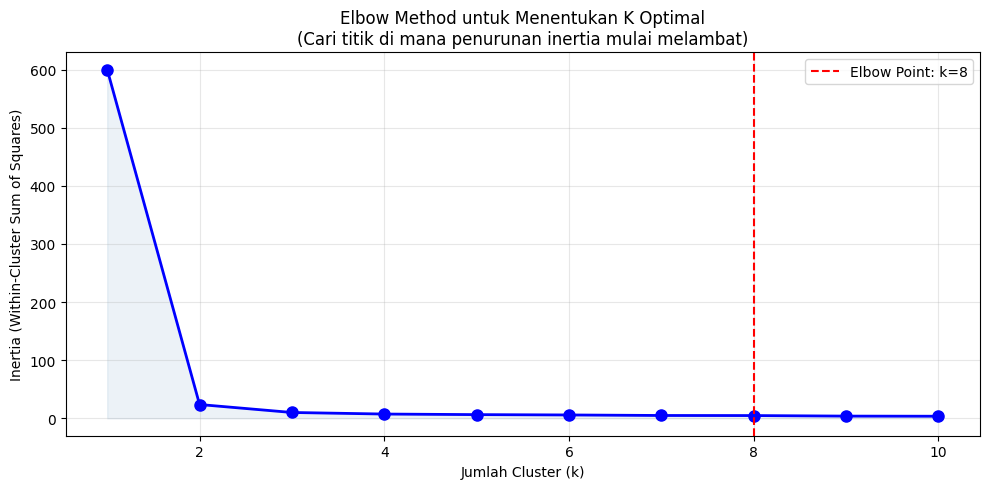

K optimal yang terdeteksi otomatis: 8
Catatan: Elbow method adalah panduan, bukan aturan mutlak.


In [4]:
# Elbow Method: Mencari K optimal
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=2024, n_init='auto')
    km.fit(X_blob)
    inertia_values.append(km.inertia_)

# Hitung perbedaan dan percepatan (second derivative)
diffs  = np.diff(inertia_values)
diffs2 = np.diff(diffs)
elbow_k = np.argmin(diffs2) + 2  # +2 karena double diff

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=elbow_k, color='red', linestyle='--',
            label=f'Elbow Point: k={elbow_k}')
plt.fill_between(k_range, inertia_values, alpha=0.1, color='steelblue')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method untuk Menentukan K Optimal\n(Cari titik di mana penurunan inertia mulai melambat)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K optimal yang terdeteksi otomatis: {elbow_k}")
print("Catatan: Elbow method adalah panduan, bukan aturan mutlak.")

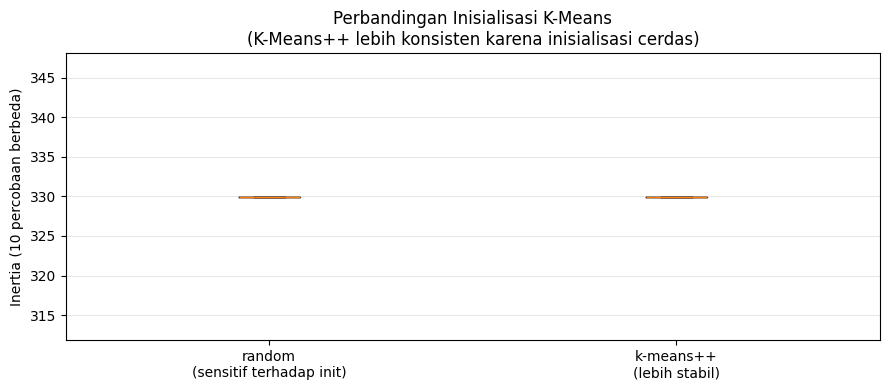

random: mean=329.98, std=0.00
k-means++: mean=329.98, std=0.00


In [5]:
# Dampak inisialisasi: K-Means biasa vs K-Means++
from sklearn.datasets import make_blobs

# Dataset lebih menantang: cluster yang tidak seimbang
X_unbal, _ = make_blobs(
    n_samples=[50, 200, 100, 300],
    centers=[[-3, 0], [0, 3], [3, 0], [0, -3]],
    cluster_std=0.5, random_state=2024
)

results_init = {}
for init_method in ['random', 'k-means++']:
    inertias = []
    for _ in range(10):  # 10 kali percobaan
        km = KMeans(n_clusters=4, init=init_method,
                    n_init=1, random_state=None)
        km.fit(X_unbal)
        inertias.append(km.inertia_)
    results_init[init_method] = inertias

plt.figure(figsize=(9, 4))
plt.boxplot(
    [results_init['random'], results_init['k-means++']],
    labels=['random\n(sensitif terhadap init)', 'k-means++\n(lebih stabil)']
)
plt.ylabel('Inertia (10 percobaan berbeda)')
plt.title('Perbandingan Inisialisasi K-Means\n(K-Means++ lebih konsisten karena inisialisasi cerdas)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

for method, vals in results_init.items():
    print(f"{method}: mean={np.mean(vals):.2f}, std={np.std(vals):.2f}")

## 3. Hierarchical Clustering (Agglomerative)

### Penjelasan Teori

**Hierarchical Clustering** membangun hierarki cluster yang bersarang. Pendekatan yang paling umum adalah **Agglomerative Clustering** (bottom-up):

**Proses Agglomerative Clustering:**
1. Mulai dengan setiap titik data sebagai cluster tersendiri.
2. Pada setiap langkah, gabungkan dua cluster yang paling dekat.
3. Terus lakukan hingga semua titik berada dalam satu cluster besar.
4. Potong hierarki pada level tertentu untuk mendapatkan K cluster.

**Metrik Linkage** menentukan bagaimana jarak antar cluster dihitung:
- **Ward (default):** Meminimalkan varians cluster yang digabungkan. Paling sering digunakan.
- **Complete:** Jarak maksimum antar semua pasangan titik dari dua cluster.
- **Average:** Rata-rata jarak antar semua pasangan titik.
- **Single:** Jarak minimum antar semua pasangan titik.

**Dendrogram:** Representasi visual dari proses penggabungan hierarki. Sumbu Y menunjukkan jarak pada saat dua cluster digabungkan. Memotong dendrogram pada ketinggian tertentu menentukan jumlah cluster.

**Kelebihan dibanding K-Means:**
- Tidak perlu menentukan K di awal.
- Dendrogram memberikan wawasan tentang struktur data pada berbagai level.
- Dapat mengidentifikasi cluster berbentuk non-bulat.

**Kekurangan:**
- Kompleksitas waktu O(n^3), tidak cocok untuk dataset sangat besar.
- Sekali titik bergabung, tidak bisa dipisah (greedy algorithm).

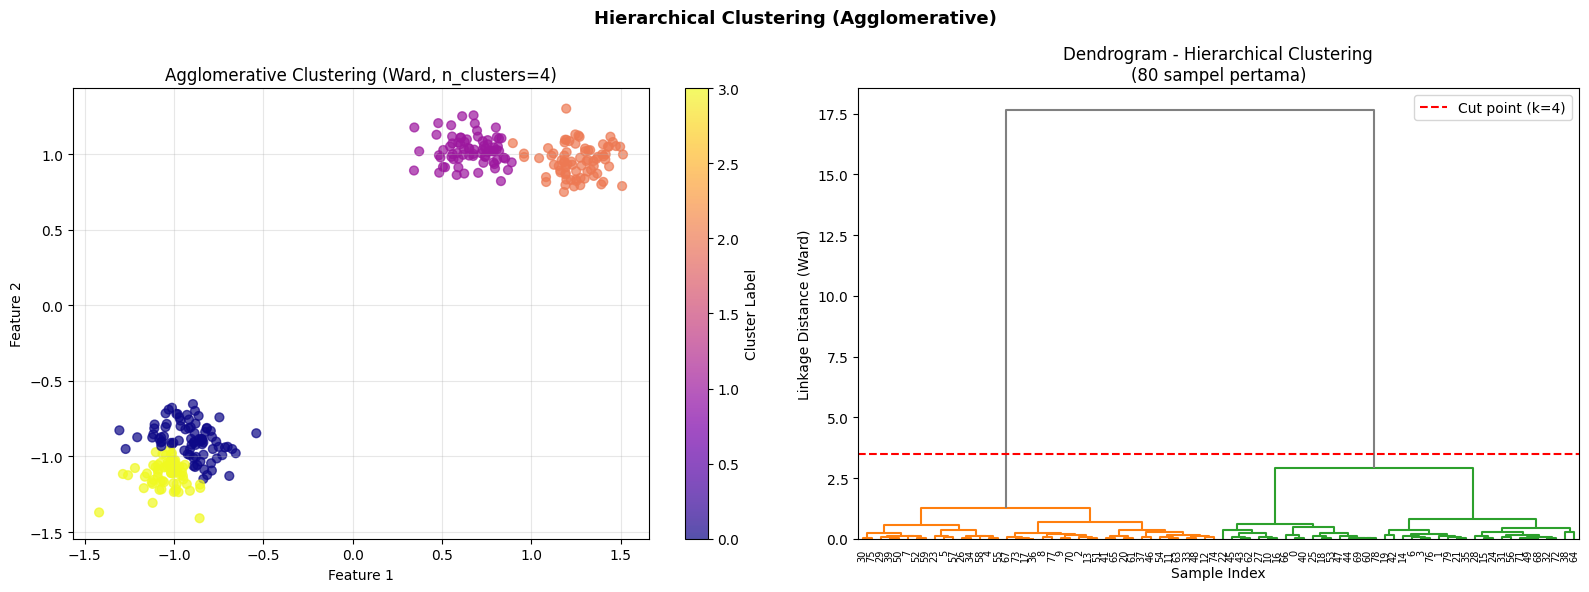

In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Agglomerative Clustering dengan 4 cluster
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_agg = agg.fit_predict(X_blob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel kiri: Hasil clustering
scatter_agg = ax1.scatter(X_blob[:, 0], X_blob[:, 1],
                          c=y_agg, cmap='plasma', s=40, alpha=0.7)
ax1.set_title('Agglomerative Clustering (Ward, n_clusters=4)')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter_agg, ax=ax1, label='Cluster Label')

# Panel kanan: Dendrogram (subset 50 sampel untuk keterbacaan)
linked = linkage(X_blob[:80], method='ward')  # gunakan subset
dendrogram(
    linked, ax=ax2, leaf_rotation=90, leaf_font_size=7,
    color_threshold=3.5,
    above_threshold_color='gray'
)
ax2.axhline(y=3.5, color='red', linestyle='--',
            label='Cut point (k=4)')
ax2.set_title('Dendrogram - Hierarchical Clustering\n(80 sampel pertama)')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Linkage Distance (Ward)')
ax2.legend()

plt.suptitle('Hierarchical Clustering (Agglomerative)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

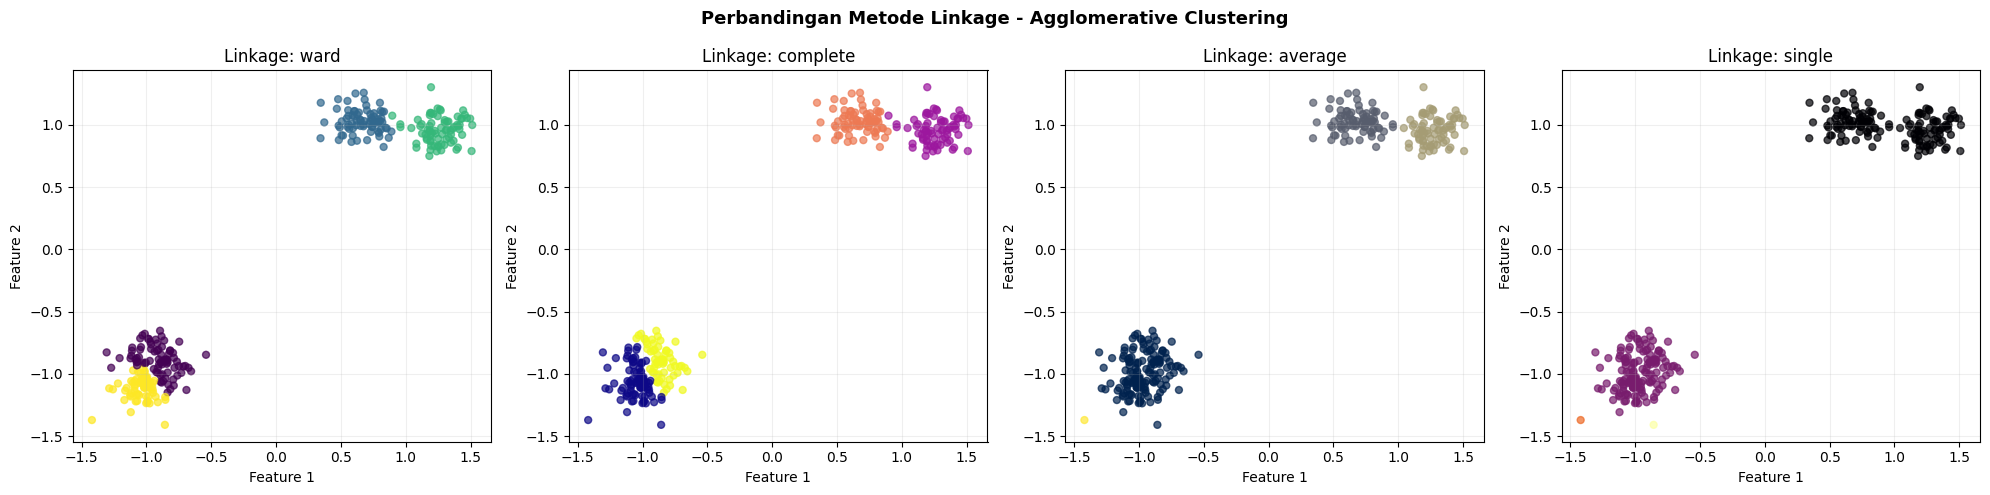

Ward: meminimalkan varians, biasanya menghasilkan cluster paling kompak dan seimbang.
Single: cenderung membuat 'rantai' panjang (chaining effect).


In [7]:
# Perbandingan metode linkage
linkage_methods = ['ward', 'complete', 'average', 'single']
colors_lm = ['viridis', 'plasma', 'cividis', 'inferno']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, method, cmap in zip(axes, linkage_methods, colors_lm):
    agg_m = AgglomerativeClustering(n_clusters=4, linkage=method)
    y_m   = agg_m.fit_predict(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1],
               c=y_m, s=25, cmap=cmap, alpha=0.7)
    ax.set_title(f'Linkage: {method}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

plt.suptitle('Perbandingan Metode Linkage - Agglomerative Clustering',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ward: meminimalkan varians, biasanya menghasilkan cluster paling kompak dan seimbang.")
print("Single: cenderung membuat 'rantai' panjang (chaining effect).")

## 4. Density-Based Clustering dengan DBSCAN

### Penjelasan Teori

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** adalah algoritma clustering berbasis kepadatan yang tidak memerlukan jumlah cluster sebagai input dan mampu menangani noise/outlier secara eksplisit.

**Dua parameter kunci DBSCAN:**
- **eps (epsilon):** Radius lingkungan di sekitar setiap titik. Mendefinisikan "neighborhood" suatu titik.
- **min_samples:** Jumlah minimum titik yang harus ada dalam radius eps untuk membentuk daerah padat (core point).

**Tiga kategori titik dalam DBSCAN:**
1. **Core Points:** Memiliki setidaknya `min_samples` titik dalam jarak `eps`.
2. **Border Points:** Berada dalam jarak `eps` dari core point, tapi tidak memiliki cukup tetangga.
3. **Noise Points (label=-1):** Bukan core point maupun border point. Ini adalah outlier.

**Kelebihan DBSCAN dibanding K-Means:**
- Tidak perlu menentukan jumlah cluster.
- Dapat menangani cluster dengan bentuk arbitrer (tidak harus bulat).
- Secara eksplisit mengidentifikasi outlier sebagai noise (label -1).
- Robust terhadap outlier.

**Kekurangan DBSCAN:**
- Sensitif terhadap pemilihan `eps` dan `min_samples`.
- Performa menurun pada data berdimensi sangat tinggi.
- Tidak cocok untuk cluster dengan kepadatan yang sangat berbeda-beda.

**K-Distance Plot:** Teknik untuk memilih nilai `eps` yang optimal. Plot jarak ke-k tetangga terdekat untuk setiap titik (diurutkan). Cari "elbow" dalam plot ini sebagai nilai `eps` yang baik.

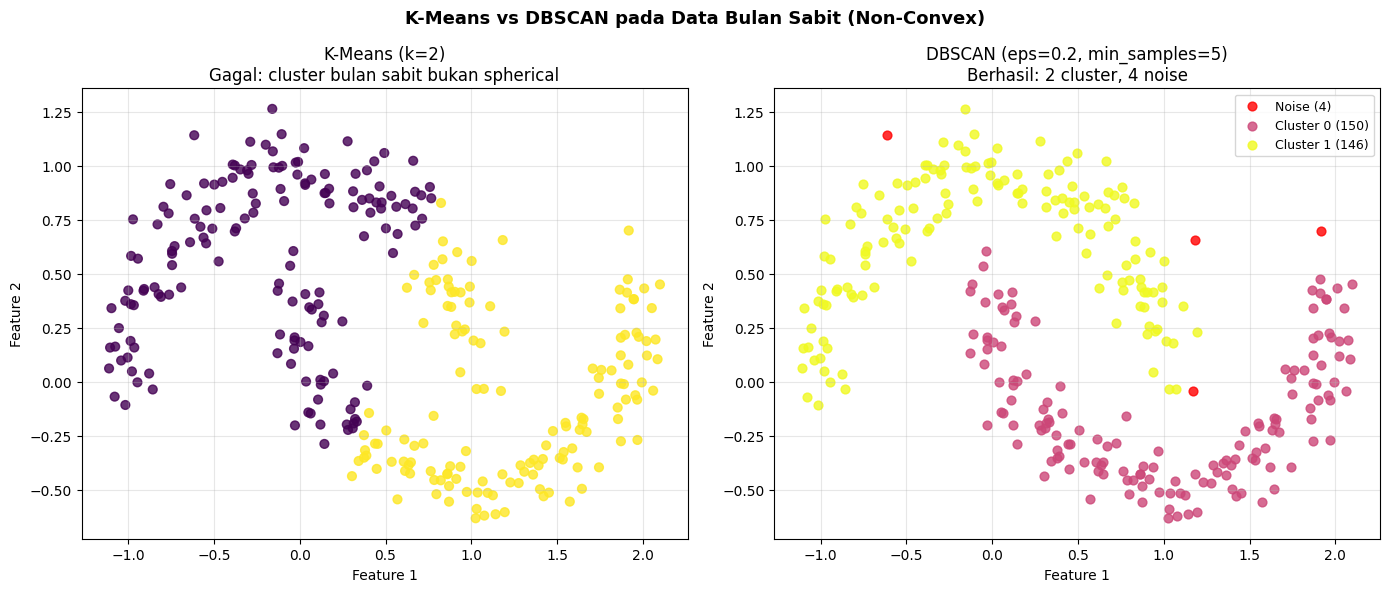

In [8]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Dataset make_moons: berbentuk bulan sabit, ideal untuk DBSCAN
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)

# Terapkan K-Means dan DBSCAN untuk perbandingan
kmeans_moon = KMeans(n_clusters=2, random_state=2024, n_init='auto')
y_km_moon   = kmeans_moon.fit_predict(X_moons)

dbscan_moon = DBSCAN(eps=0.2, min_samples=5)
y_db_moon   = dbscan_moon.fit_predict(X_moons)

n_clusters_db = len(set(y_db_moon)) - (1 if -1 in y_db_moon else 0)
n_noise_db    = (y_db_moon == -1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_moons[:, 0], X_moons[:, 1],
            c=y_km_moon, cmap='viridis', s=40, alpha=0.8)
ax1.set_title(f'K-Means (k=2)\nGagal: cluster bulan sabit bukan spherical')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

unique_labels = set(y_db_moon)
palette = plt.cm.plasma(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(sorted(unique_labels), palette):
    mask = y_db_moon == label
    lbl  = f'Noise ({mask.sum()})' if label == -1 else f'Cluster {label} ({mask.sum()})'
    col  = 'red' if label == -1 else color
    ax2.scatter(X_moons[mask, 0], X_moons[mask, 1],
                c=[col], s=40, alpha=0.8, label=lbl)
ax2.set_title(f'DBSCAN (eps=0.2, min_samples=5)\nBerhasil: {n_clusters_db} cluster, {n_noise_db} noise')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('K-Means vs DBSCAN pada Data Bulan Sabit (Non-Convex)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

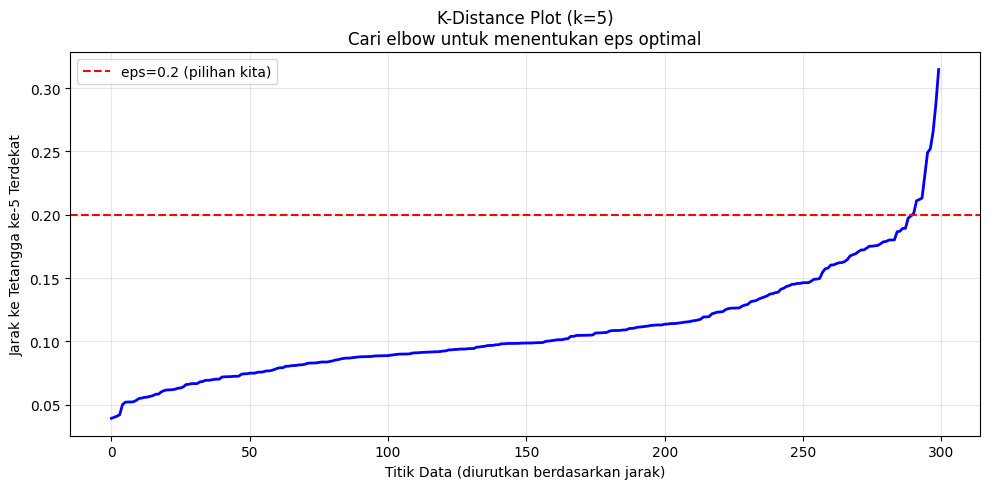

Panduan membaca k-distance plot:
  - Di sebelah kiri: titik padat (jarak ke tetangga kecil = core/border points)
  - Di sebelah kanan: titik jarang/noise (jarak ke tetangga besar)
  - Elbow point: nilai eps yang memisahkan dua kelompok ini


In [9]:
# K-Distance Plot: panduan memilih nilai eps optimal
from sklearn.neighbors import NearestNeighbors

min_samples_val = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_val)
nbrs.fit(X_moons)
distances, _ = nbrs.kneighbors(X_moons)

# Ambil jarak ke tetangga ke-k (kolom terakhir) dan urutkan
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=2)
plt.axhline(y=0.2, color='red', linestyle='--',
            label='eps=0.2 (pilihan kita)')
plt.xlabel('Titik Data (diurutkan berdasarkan jarak)')
plt.ylabel(f'Jarak ke Tetangga ke-{min_samples_val} Terdekat')
plt.title(f'K-Distance Plot (k={min_samples_val})\nCari elbow untuk menentukan eps optimal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Panduan membaca k-distance plot:")
print("  - Di sebelah kiri: titik padat (jarak ke tetangga kecil = core/border points)")
print("  - Di sebelah kanan: titik jarang/noise (jarak ke tetangga besar)")
print("  - Elbow point: nilai eps yang memisahkan dua kelompok ini")

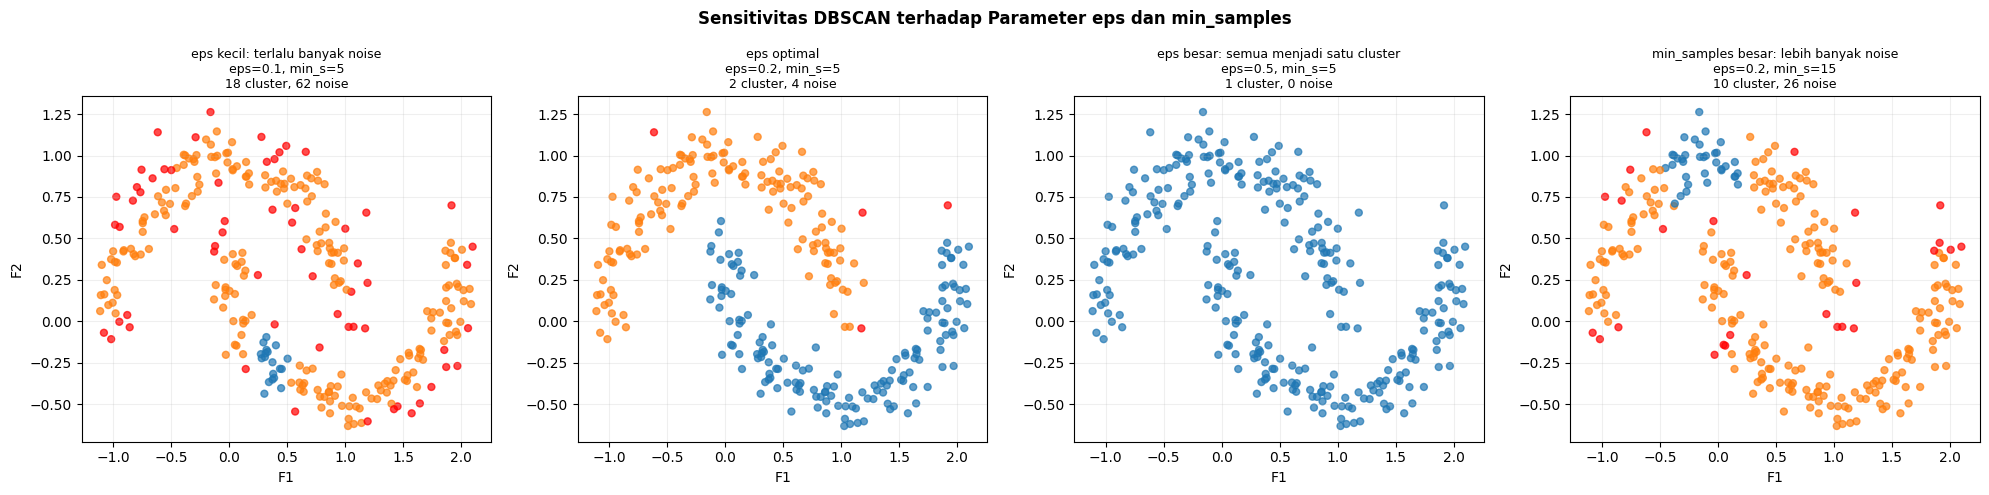

In [10]:
# Dampak eps dan min_samples pada hasil DBSCAN
configs_db = [
    (0.1, 5, 'eps kecil: terlalu banyak noise'),
    (0.2, 5, 'eps optimal'),
    (0.5, 5, 'eps besar: semua menjadi satu cluster'),
    (0.2, 15, 'min_samples besar: lebih banyak noise'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (eps_v, ms_v, title) in zip(axes, configs_db):
    db_tmp = DBSCAN(eps=eps_v, min_samples=ms_v)
    y_tmp  = db_tmp.fit_predict(X_moons)
    n_cl   = len(set(y_tmp)) - (1 if -1 in y_tmp else 0)
    n_ns   = (y_tmp == -1).sum()

    # Noise dalam merah, cluster dalam warna berbeda
    colors_tmp = np.where(y_tmp == -1, 'red',
                 np.where(y_tmp == 0, '#1f77b4', '#ff7f0e'))
    ax.scatter(X_moons[:, 0], X_moons[:, 1],
               c=colors_tmp, s=25, alpha=0.7)
    ax.set_title(f'{title}\neps={eps_v}, min_s={ms_v}\n{n_cl} cluster, {n_ns} noise',
                 fontsize=9)
    ax.set_xlabel('F1')
    ax.set_ylabel('F2')
    ax.grid(True, alpha=0.2)

plt.suptitle('Sensitivitas DBSCAN terhadap Parameter eps dan min_samples',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Cluster Evaluation Metrics

### Penjelasan Teori

Evaluasi clustering lebih sulit dari supervised learning karena tidak ada "jawaban benar" yang jelas. Ada dua kategori metrik:

**Metrik Internal (tidak memerlukan ground truth):**

1. **Silhouette Score:**
   - Mengukur seberapa mirip setiap titik dengan cluster-nya sendiri dibanding cluster lain.
   - Range: -1 (buruk) hingga +1 (sempurna).
   - Formula: `s(i) = (b(i) - a(i)) / max(a(i), b(i))`
   - di mana `a(i)` = jarak rata-rata ke sesama anggota cluster, `b(i)` = jarak rata-rata ke cluster terdekat lainnya.

2. **Davies-Bouldin Index:**
   - Mengukur rasio dispersi intra-cluster terhadap separasi inter-cluster.
   - **Nilai lebih rendah = clustering lebih baik** (berbeda dari Silhouette).
   - Menghukum cluster yang tumpang tindih.

3. **Calinski-Harabasz Index (Variance Ratio Criterion):**
   - Mengukur rasio dispersi antar-cluster terhadap dispersi intra-cluster.
   - **Nilai lebih tinggi = clustering lebih baik**.

**Metrik Eksternal (memerlukan ground truth):**

4. **Adjusted Rand Index (ARI):**
   - Membandingkan hasil clustering dengan label kelas yang sebenarnya.
   - Range: -1 hingga +1. Nilai 1 = perfect match.
   - Koreksi untuk chance (random clustering mendapat nilai 0).
   - Hanya bisa digunakan ketika ground truth tersedia (misalnya saat mengevaluasi pada dataset yang sebenarnya berlabel).

In [11]:
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, calinski_harabasz_score
)

# Generate dataset dengan ground truth untuk evaluasi komprehensif
X_eval, y_true_eval = make_blobs(
    n_samples=300, centers=4,
    cluster_std=0.60, random_state=2024
)

# Hitung metrik untuk K-Means
kmeans_eval = KMeans(n_clusters=4, random_state=2024, n_init='auto')
y_km_eval   = kmeans_eval.fit_predict(X_eval)

sil_km  = silhouette_score(X_eval, y_km_eval)
db_km   = davies_bouldin_score(X_eval, y_km_eval)
ch_km   = calinski_harabasz_score(X_eval, y_km_eval)
ari_km  = adjusted_rand_score(y_true_eval, y_km_eval)

print("Evaluasi K-Means (k=4) pada dataset blob:")
print(f"  Silhouette Score:         {sil_km:.4f}  (tinggi = baik, range -1 to 1)")
print(f"  Davies-Bouldin Index:     {db_km:.4f}  (rendah = baik)")
print(f"  Calinski-Harabasz Index:  {ch_km:.2f} (tinggi = baik)")
print(f"  Adjusted Rand Index:      {ari_km:.4f}  (1 = perfect, 0 = random)")

Evaluasi K-Means (k=4) pada dataset blob:
  Silhouette Score:         0.5343  (tinggi = baik, range -1 to 1)
  Davies-Bouldin Index:     0.7017  (rendah = baik)
  Calinski-Harabasz Index:  8670.78 (tinggi = baik)
  Adjusted Rand Index:      0.8138  (1 = perfect, 0 = random)


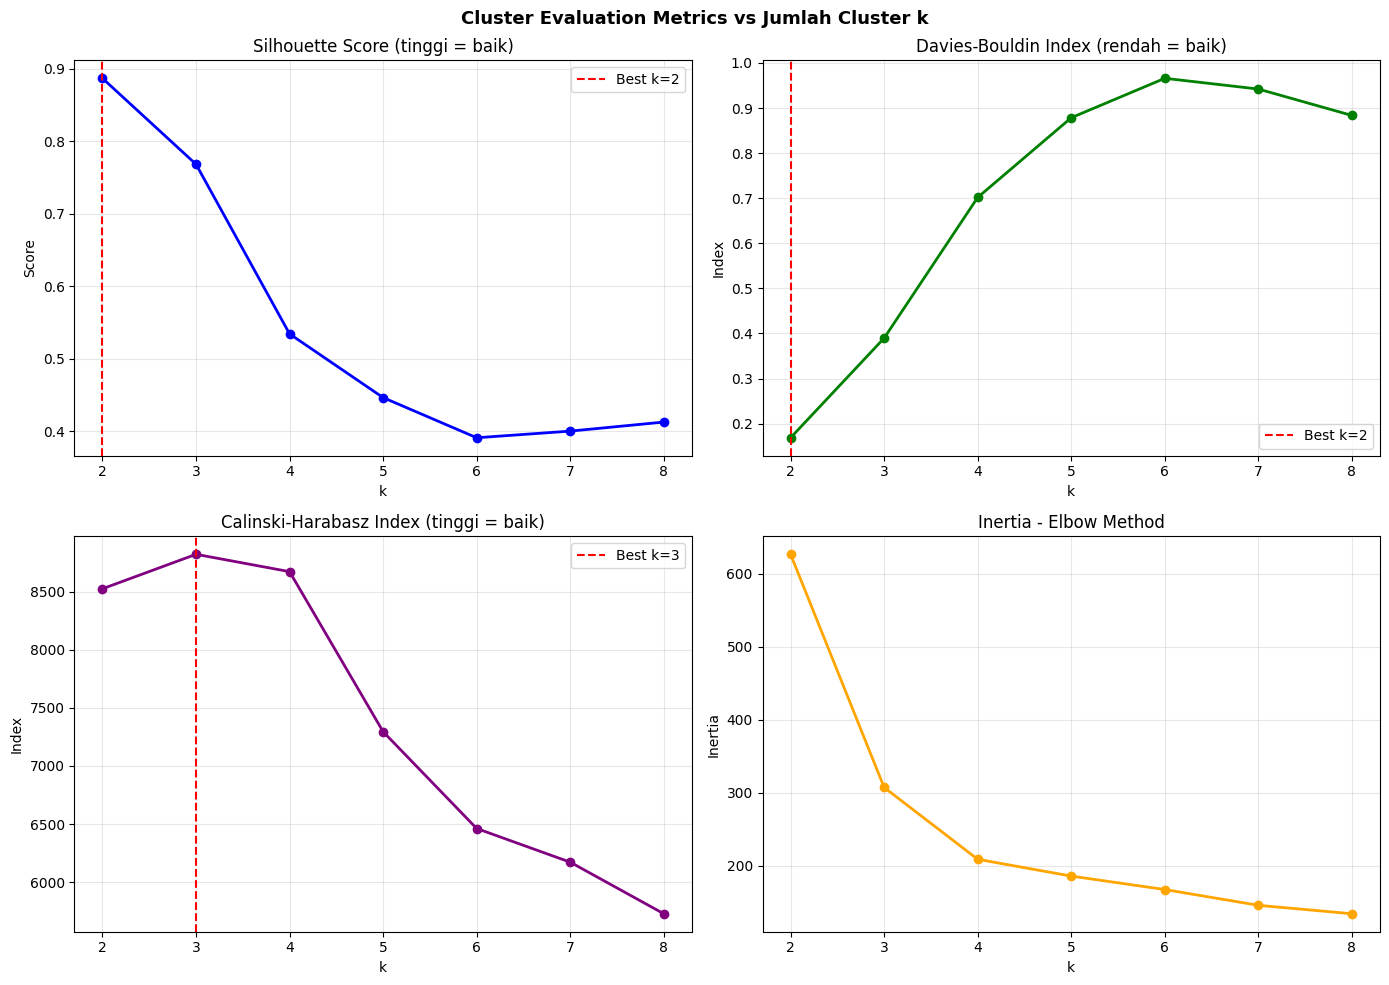

K optimal menurut Silhouette:        k=2
K optimal menurut Davies-Bouldin:    k=2
K optimal menurut Calinski-Harabasz: k=3


In [12]:
# Gunakan Silhouette Score untuk memilih k optimal
k_range_eval = range(2, 9)
metrics_results = {
    'k': [], 'silhouette': [], 'davies_bouldin': [],
    'calinski_harabasz': [], 'inertia': []
}

for k in k_range_eval:
    km = KMeans(n_clusters=k, random_state=2024, n_init='auto')
    labels = km.fit_predict(X_eval)
    metrics_results['k'].append(k)
    metrics_results['silhouette'].append(silhouette_score(X_eval, labels))
    metrics_results['davies_bouldin'].append(davies_bouldin_score(X_eval, labels))
    metrics_results['calinski_harabasz'].append(calinski_harabasz_score(X_eval, labels))
    metrics_results['inertia'].append(km.inertia_)

metrics_df = pd.DataFrame(metrics_results)
best_k_sil = metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k']
best_k_db  = metrics_df.loc[metrics_df['davies_bouldin'].idxmin(), 'k']
best_k_ch  = metrics_df.loc[metrics_df['calinski_harabasz'].idxmax(), 'k']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Silhouette
axes[0,0].plot(metrics_df['k'], metrics_df['silhouette'], 'b-o', lw=2)
axes[0,0].axvline(x=best_k_sil, color='red', ls='--', label=f'Best k={best_k_sil}')
axes[0,0].set_title('Silhouette Score (tinggi = baik)')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Score')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Davies-Bouldin
axes[0,1].plot(metrics_df['k'], metrics_df['davies_bouldin'], 'g-o', lw=2)
axes[0,1].axvline(x=best_k_db, color='red', ls='--', label=f'Best k={best_k_db}')
axes[0,1].set_title('Davies-Bouldin Index (rendah = baik)')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Index')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[1,0].plot(metrics_df['k'], metrics_df['calinski_harabasz'], 'purple', marker='o', lw=2)
axes[1,0].axvline(x=best_k_ch, color='red', ls='--', label=f'Best k={best_k_ch}')
axes[1,0].set_title('Calinski-Harabasz Index (tinggi = baik)')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('Index')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Inertia (Elbow)
axes[1,1].plot(metrics_df['k'], metrics_df['inertia'], 'orange', marker='o', lw=2)
axes[1,1].set_title('Inertia - Elbow Method')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('Inertia')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Cluster Evaluation Metrics vs Jumlah Cluster k',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"K optimal menurut Silhouette:        k={best_k_sil}")
print(f"K optimal menurut Davies-Bouldin:    k={best_k_db}")
print(f"K optimal menurut Calinski-Harabasz: k={best_k_ch}")

## 6. Panduan Memilih Algoritma Clustering

### Penjelasan Teori

Pemilihan algoritma clustering yang tepat sangat bergantung pada karakteristik data. Tidak ada satu algoritma yang terbaik untuk semua kasus.

| Karakteristik Data | Algoritma yang Direkomendasikan |
|-------------------|--------------------------------|
| Cluster berbentuk bola (spherical), ukuran seimbang | K-Means |
| Cluster berbentuk non-konveks (bulan, cincin) | DBSCAN, Spectral Clustering |
| Terdapat noise/outlier signifikan | DBSCAN |
| Dataset kecil, struktur hierarkis penting | Hierarchical Clustering |
| Dataset sangat besar (jutaan sampel) | MiniBatchKMeans |
| Distribusi probabilistik, cluster tumpang tindih | Gaussian Mixture Models |
| Dimensi sangat tinggi | K-Means + PCA, atau Linear SVM berbasis clustering |

**Pendekatan praktis yang disarankan:**
1. **Visualisasikan data** terlebih dahulu untuk memahami bentuk dan struktur.
2. **Coba K-Means** sebagai baseline.
3. Jika ada outlier atau bentuk non-spherical, **coba DBSCAN**.
4. Gunakan **metrik evaluasi** untuk membandingkan secara objektif.
5. Pertimbangkan domain knowledge untuk interpretasi hasil.

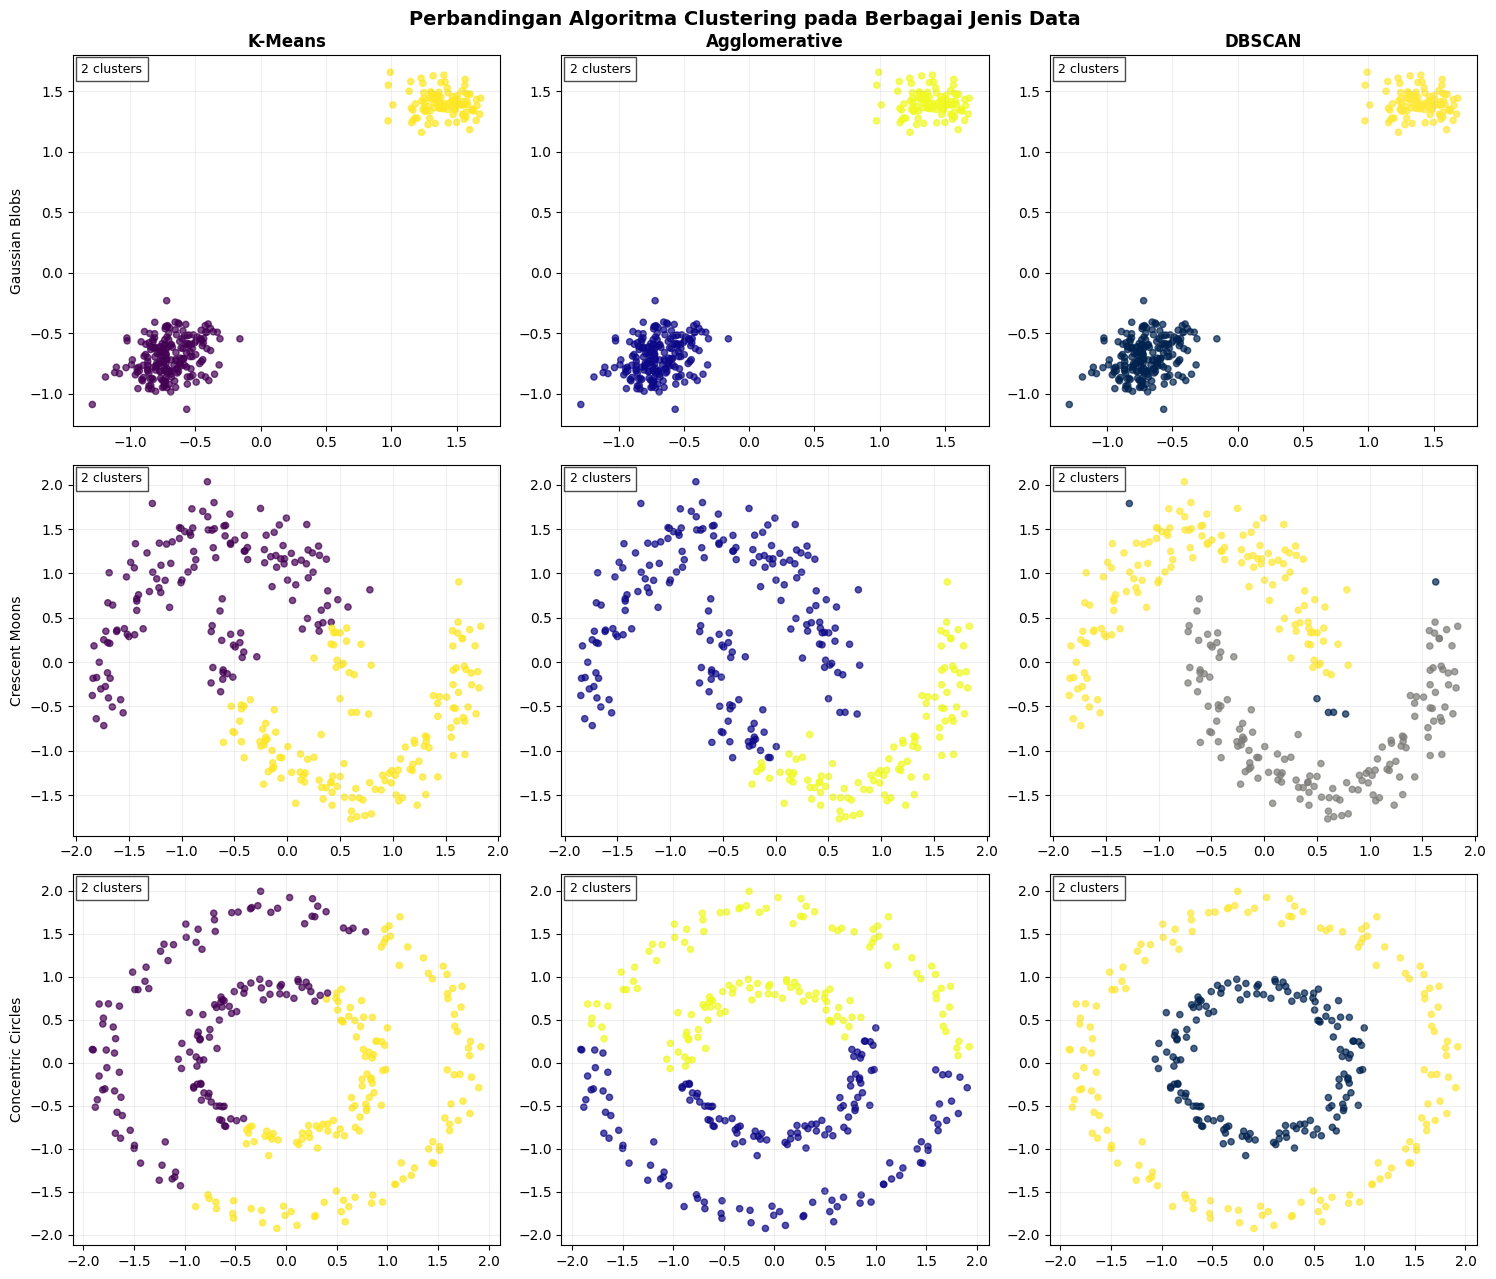

Pengamatan:
  K-Means: bekerja baik untuk Gaussian Blobs, gagal untuk Moons dan Circles.
  Agglomerative (Ward): serupa dengan K-Means, masih kesulitan dengan bentuk non-konveks.
  DBSCAN: paling fleksibel, berhasil untuk semua bentuk cluster.


In [13]:
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler

# Buat tiga jenis dataset berbeda
X_blobs_cmp, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=2024)
X_moons_cmp, _ = make_moons(n_samples=300, noise=0.1, random_state=2024)
X_circ_cmp, _  = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=2024)

datasets = [
    (StandardScaler().fit_transform(X_blobs_cmp), 'Gaussian Blobs'),
    (StandardScaler().fit_transform(X_moons_cmp), 'Crescent Moons'),
    (StandardScaler().fit_transform(X_circ_cmp),  'Concentric Circles'),
]

algorithms = [
    ('K-Means',   lambda X: KMeans(n_clusters=2, random_state=2024, n_init='auto').fit_predict(X)
                  if X.shape == datasets[0][0].shape else
                  KMeans(n_clusters=2, random_state=2024, n_init='auto').fit_predict(X)),
    ('Agglomerative', lambda X: AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X)),
    ('DBSCAN',    lambda X: DBSCAN(eps=0.3, min_samples=5).fit_predict(X)),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
cmaps_algo = ['viridis', 'plasma', 'cividis']

for col, (algo_name, algo_fn) in enumerate(algorithms):
    for row, (X_data, data_name) in enumerate(datasets):
        y_pred_cmp = algo_fn(X_data)
        n_cl = len(set(y_pred_cmp)) - (1 if -1 in y_pred_cmp else 0)
        axes[row, col].scatter(X_data[:, 0], X_data[:, 1],
                               c=y_pred_cmp, cmap=cmaps_algo[col], s=20, alpha=0.7)
        if row == 0:
            axes[row, col].set_title(algo_name, fontsize=12, fontweight='bold')
        axes[row, col].set_ylabel(data_name if col == 0 else '')
        axes[row, col].text(0.02, 0.98, f'{n_cl} clusters',
                            transform=axes[row, col].transAxes,
                            va='top', fontsize=9,
                            bbox=dict(facecolor='white', alpha=0.7))
        axes[row, col].grid(True, alpha=0.2)

plt.suptitle('Perbandingan Algoritma Clustering pada Berbagai Jenis Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Pengamatan:")
print("  K-Means: bekerja baik untuk Gaussian Blobs, gagal untuk Moons dan Circles.")
print("  Agglomerative (Ward): serupa dengan K-Means, masih kesulitan dengan bentuk non-konveks.")
print("  DBSCAN: paling fleksibel, berhasil untuk semua bentuk cluster.")

## 7. Teknik Lanjutan: Spectral Clustering dan GMM

### Penjelasan Teori

**Spectral Clustering:**
Algoritma yang lebih canggih yang menggunakan teori spektral (eigenvalue/eigenvector dari matriks kemiripan) untuk menemukan cluster. Prosesnya:
1. Bangun similarity graph dari data.
2. Hitung matriks Laplacian dari graph.
3. Proyeksikan data ke ruang dimensi rendah menggunakan eigenvector.
4. Terapkan K-Means pada representasi yang diproyeksikan.

Spectral clustering sangat efektif untuk cluster non-konveks dan data dengan banyak fitur.

**Gaussian Mixture Models (GMM):**
GMM adalah pendekatan **soft clustering** berbasis probabilistik yang mengasumsikan data dihasilkan dari campuran beberapa distribusi Gaussian:
- Setiap cluster direpresentasikan sebagai distribusi Gaussian dengan mean dan covariance tertentu.
- Setiap titik data mendapat **probabilitas** untuk termasuk dalam setiap cluster (bukan assignment binary).
- Menggunakan algoritma **Expectation-Maximization (EM)** untuk menemukan parameter.
- `predict_proba()` mengembalikan probabilitas keanggotaan setiap cluster.

**Kapan menggunakan GMM:**
- Ketika cluster mungkin tumpang tindih.
- Ketika Anda memerlukan probabilitas keanggotaan (bukan hanya label hard).
- Ketika cluster memiliki bentuk eliptis yang berbeda.
- Untuk anomaly detection: titik dengan probabilitas rendah di semua cluster adalah anomali.

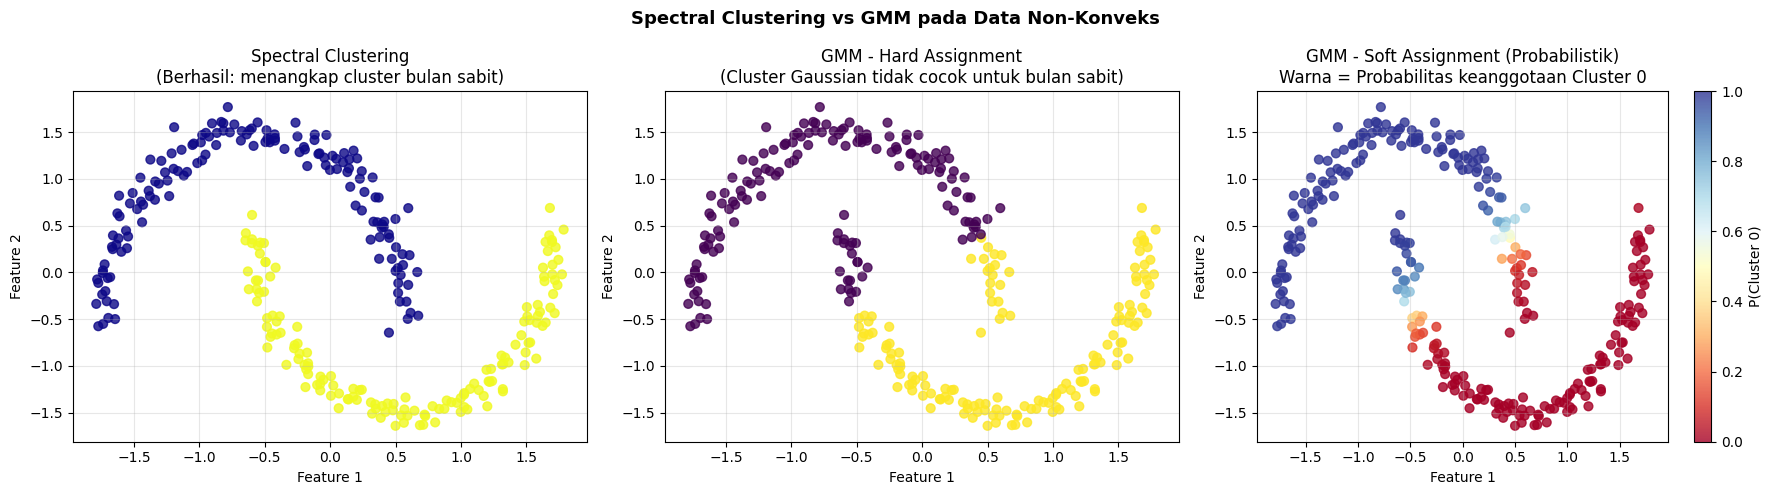

In [14]:
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture

# Dataset: dua bulan sabit
X_adv, _ = make_moons(n_samples=300, noise=0.05, random_state=2024)
X_adv     = StandardScaler().fit_transform(X_adv)

# Terapkan Spectral Clustering dan GMM
spectral = SpectralClustering(
    n_clusters=2, affinity='nearest_neighbors',
    n_neighbors=10, random_state=2024
)
y_spectral = spectral.fit_predict(X_adv)

gmm = GaussianMixture(n_components=2, random_state=2024)
gmm.fit(X_adv)
y_gmm      = gmm.predict(X_adv)
proba_gmm  = gmm.predict_proba(X_adv)  # soft assignment

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Spectral Clustering
axes[0].scatter(X_adv[:, 0], X_adv[:, 1],
                c=y_spectral, cmap='plasma', s=40, alpha=0.8)
axes[0].set_title('Spectral Clustering\n(Berhasil: menangkap cluster bulan sabit)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# Panel 2: GMM hard assignment
axes[1].scatter(X_adv[:, 0], X_adv[:, 1],
                c=y_gmm, cmap='viridis', s=40, alpha=0.8)
axes[1].set_title('GMM - Hard Assignment\n(Cluster Gaussian tidak cocok untuk bulan sabit)')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')
axes[1].grid(True, alpha=0.3)

# Panel 3: GMM soft assignment (warna berdasarkan probabilitas)
scatter_gmm = axes[2].scatter(X_adv[:, 0], X_adv[:, 1],
                              c=proba_gmm[:, 0], cmap='RdYlBu',
                              s=40, alpha=0.8, vmin=0, vmax=1)
plt.colorbar(scatter_gmm, ax=axes[2], label='P(Cluster 0)')
axes[2].set_title('GMM - Soft Assignment (Probabilistik)\nWarna = Probabilitas keanggotaan Cluster 0')
axes[2].set_xlabel('Feature 1'); axes[2].set_ylabel('Feature 2')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Spectral Clustering vs GMM pada Data Non-Konveks',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

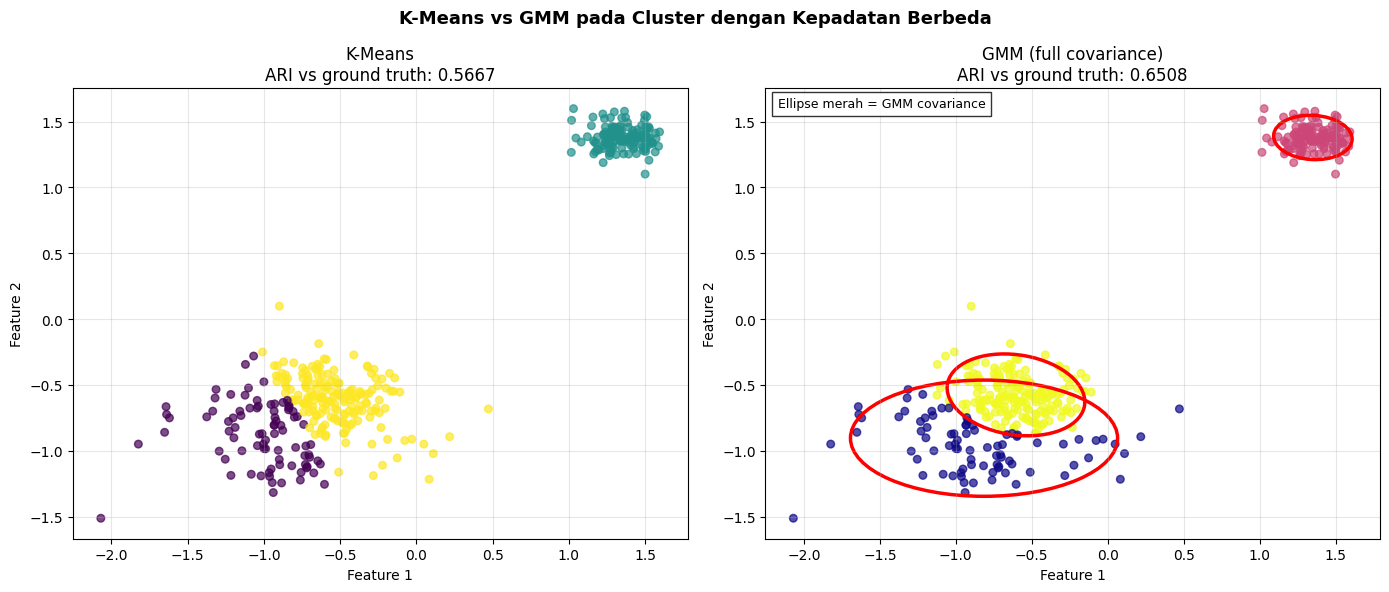

GMM dapat menangkap bentuk elliptis cluster karena memodelkan
covariance matrix secara penuh, sedangkan K-Means mengasumsikan spherical.


In [15]:
# GMM pada Gaussian Blobs: kekuatan GMM yang sesungguhnya
X_gmm_blob, y_true_gmm = make_blobs(
    n_samples=400, centers=3, cluster_std=[0.5, 1.5, 0.8],
    random_state=2024
)
X_gmm_blob = StandardScaler().fit_transform(X_gmm_blob)

# Perbandingan K-Means vs GMM pada data dengan kepadatan berbeda
km_blob  = KMeans(n_clusters=3, random_state=2024, n_init='auto')
y_km_bl  = km_blob.fit_predict(X_gmm_blob)

gmm_blob = GaussianMixture(n_components=3, random_state=2024, covariance_type='full')
gmm_blob.fit(X_gmm_blob)
y_gm_bl  = gmm_blob.predict(X_gmm_blob)
proba_bl = gmm_blob.predict_proba(X_gmm_blob)

ari_km_bl = adjusted_rand_score(y_true_gmm, y_km_bl)
ari_gm_bl = adjusted_rand_score(y_true_gmm, y_gm_bl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X_gmm_blob[:, 0], X_gmm_blob[:, 1],
            c=y_km_bl, cmap='viridis', s=30, alpha=0.7)
ax1.set_title(f'K-Means\nARI vs ground truth: {ari_km_bl:.4f}')
ax1.set_xlabel('Feature 1'); ax1.set_ylabel('Feature 2')
ax1.grid(True, alpha=0.3)

ax2.scatter(X_gmm_blob[:, 0], X_gmm_blob[:, 1],
            c=y_gm_bl, cmap='plasma', s=30, alpha=0.7)
ax2.set_title(f'GMM (full covariance)\nARI vs ground truth: {ari_gm_bl:.4f}')
ax2.set_xlabel('Feature 1'); ax2.set_ylabel('Feature 2')
ax2.grid(True, alpha=0.3)

# Plot ellipse GMM
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_gmm_ellipse(ax, gmm_model, n_std=2, color='red'):
    for mean, cov in zip(gmm_model.means_, gmm_model.covariances_):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        w, h  = 2 * n_std * np.sqrt(vals)
        ell   = Ellipse(xy=mean, width=w, height=h, angle=theta,
                        edgecolor=color, facecolor='none', lw=2.5)
        ax.add_patch(ell)

plot_gmm_ellipse(ax2, gmm_blob, color='red')
ax2.text(0.02, 0.98, 'Ellipse merah = GMM covariance',
         transform=ax2.transAxes, va='top', fontsize=9,
         bbox=dict(facecolor='white', alpha=0.8))

plt.suptitle('K-Means vs GMM pada Cluster dengan Kepadatan Berbeda',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"GMM dapat menangkap bentuk elliptis cluster karena memodelkan")
print(f"covariance matrix secara penuh, sedangkan K-Means mengasumsikan spherical.")

## 8. Latihan Praktis: Clustering pada Dataset Iris

### Deskripsi

Pada bagian ini kita menerapkan semua teknik clustering yang dipelajari pada dataset Iris yang sesungguhnya. Meski Iris sebenarnya berlabel (supervised), kita akan mengabaikan labelnya dan mengevaluasi seberapa baik clustering dapat merecovery kelompok alami yang ada.

In [16]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load Iris dataset (label diabaikan saat clustering, digunakan hanya untuk evaluasi)
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris_true = iris.target

print(f"Dataset Iris: {X_iris.shape[0]} sampel, {X_iris.shape[1]} fitur")
print(f"Kelas (untuk evaluasi saja): {iris.target_names}")

# PCA untuk visualisasi 2D
pca_iris = PCA(n_components=2)
X_iris_2d = pca_iris.fit_transform(X_iris)
print(f"Variance yang dijelaskan oleh 2 PC: {pca_iris.explained_variance_ratio_.sum():.2%}")

Dataset Iris: 150 sampel, 4 fitur
Kelas (untuk evaluasi saja): ['setosa' 'versicolor' 'virginica']
Variance yang dijelaskan oleh 2 PC: 95.81%


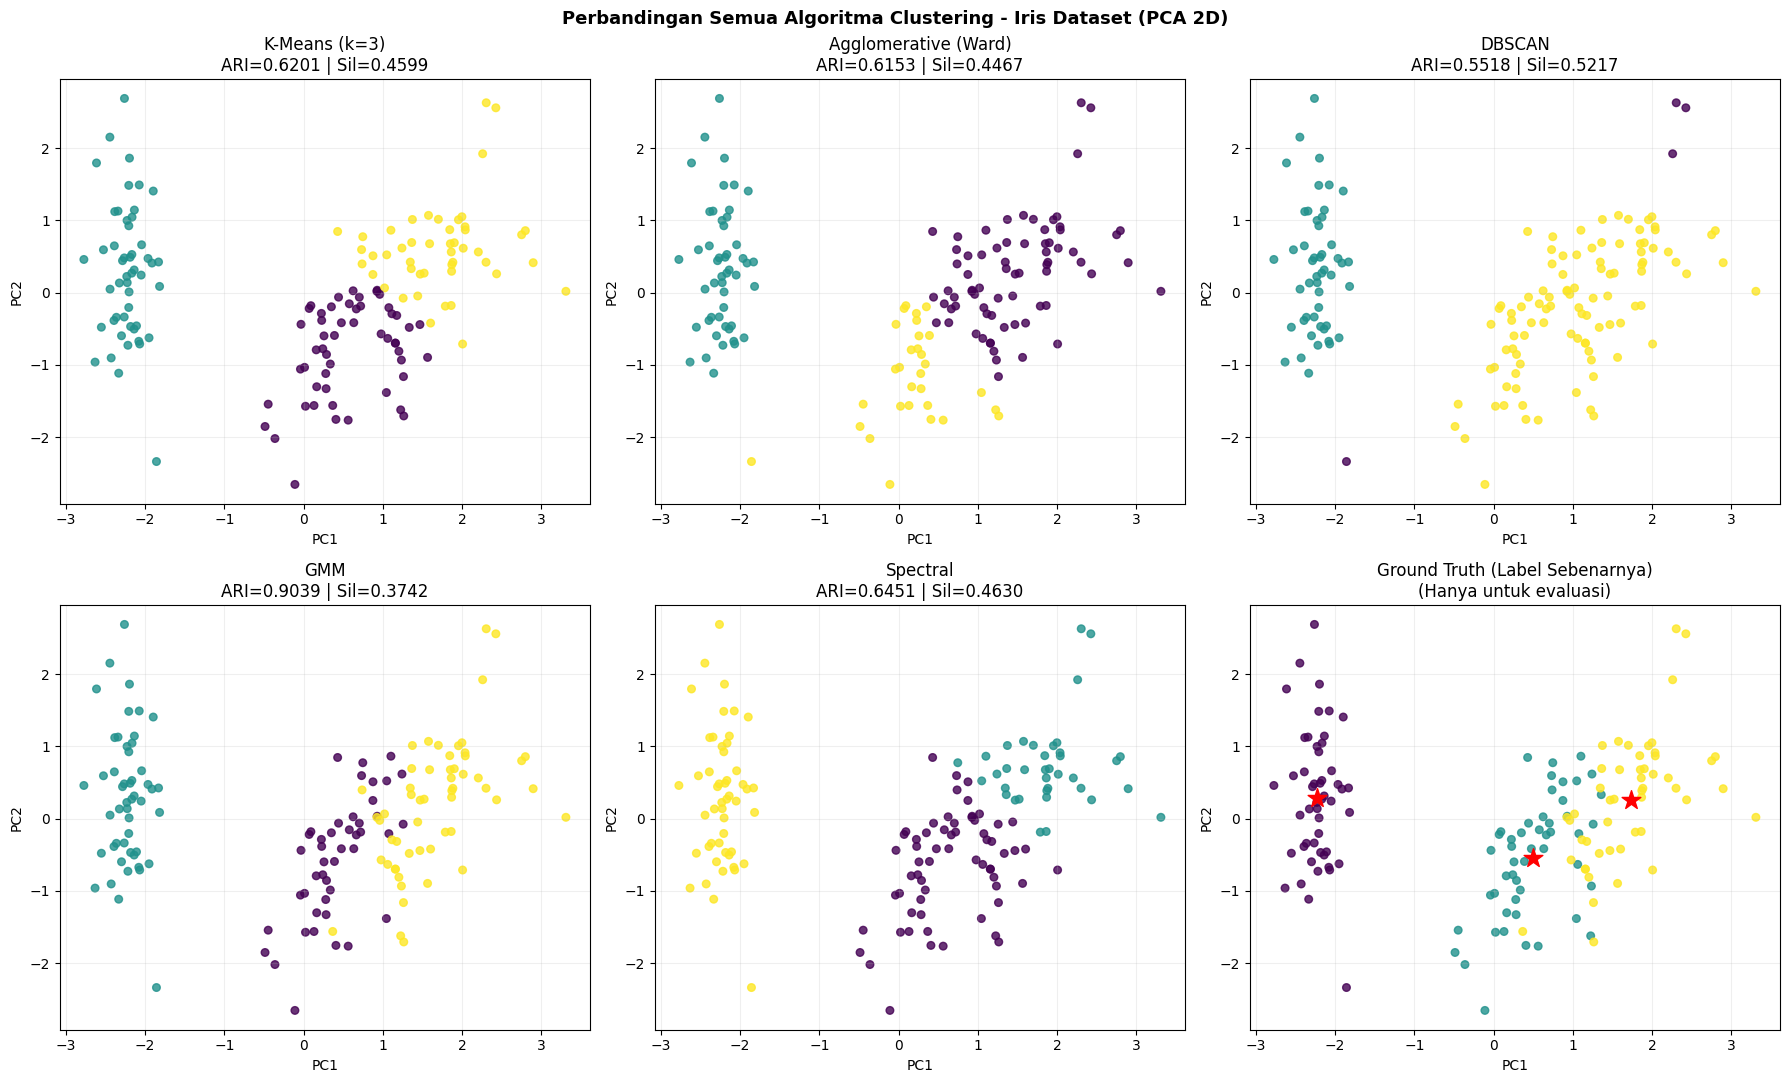


Ringkasan Metrik Evaluasi:


,Algoritma,Clusters,Silhouette,ARI,Davies-Bouldin
0,K-Means (k=3),3,0.4599,0.6201,0.8336
1,Agglomerative (Ward),3,0.4467,0.6153,0.8035
2,DBSCAN,2,0.5217,0.5518,1.9432
3,GMM,3,0.3742,0.9039,1.0809
4,Spectral,3,0.4630,0.6451,0.8257


In [19]:
# Terapkan semua algoritma clustering pada Iris
algos_iris = {
    'K-Means (k=3)': KMeans(n_clusters=3, random_state=2024, n_init='auto'),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=3, linkage='ward'),
    'DBSCAN': DBSCAN(eps=0.8, min_samples=5),
    'GMM': GaussianMixture(n_components=3, random_state=2024),
    'Spectral': SpectralClustering(n_clusters=3, random_state=2024, n_neighbors=10),
}

iris_results = []
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat  = axes.flatten()

for i, (name, algo) in enumerate(algos_iris.items()):
    labels = algo.fit_predict(X_iris)
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)

    sil  = silhouette_score(X_iris, labels) if n_cl >= 2 else None
    ari  = adjusted_rand_score(y_iris_true, labels)
    db   = davies_bouldin_score(X_iris, labels) if n_cl >= 2 else None

    iris_results.append({
        'Algoritma': name, 'Clusters': n_cl,
        'Silhouette': round(sil, 4) if sil else 'N/A',
        'ARI': round(ari, 4),
        'Davies-Bouldin': round(db, 4) if db else 'N/A',
    })

    axes_flat[i].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8)
    axes_flat[i].set_title(f'{name}\nARI={ari:.4f} | Sil={f"{sil:.4f}" if sil is not None else "N/A"}')
    axes_flat[i].set_xlabel('PC1'); axes_flat[i].set_ylabel('PC2')
    axes_flat[i].grid(True, alpha=0.2)

# Panel terakhir: ground truth
axes_flat[5].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1],
                     c=y_iris_true, cmap='viridis', s=30, alpha=0.8)
for cls, name in enumerate(iris.target_names):
    mask = y_iris_true == cls
    axes_flat[5].scatter(X_iris_2d[mask, 0].mean(), X_iris_2d[mask, 1].mean(),
                         s=200, marker='*', c='red', zorder=5)
axes_flat[5].set_title('Ground Truth (Label Sebenarnya)\n(Hanya untuk evaluasi)')
axes_flat[5].set_xlabel('PC1'); axes_flat[5].set_ylabel('PC2')
axes_flat[5].grid(True, alpha=0.2)

plt.suptitle('Perbandingan Semua Algoritma Clustering - Iris Dataset (PCA 2D)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

results_df_iris = pd.DataFrame(iris_results)
print("\nRingkasan Metrik Evaluasi:")
display(results_df_iris)

## Ringkasan Chapter 10

| Algoritma | Kelas scikit-learn | Tipe | Butuh K? | Menangani Noise? | Bentuk Cluster |
|-----------|-------------------|------|----------|-----------------|----------------|
| K-Means | `KMeans()` | Centroid-based | Ya | Tidak | Spherical |
| Agglomerative | `AgglomerativeClustering()` | Connectivity-based | Ya* | Tidak | Fleksibel |
| DBSCAN | `DBSCAN()` | Density-based | Tidak | Ya (-1) | Arbitrer |
| Spectral | `SpectralClustering()` | Spectral graph | Ya | Tidak | Non-konveks |
| GMM | `GaussianMixture()` | Probabilistic | Ya | Tidak | Elliptical |

*Dapat menggunakan `distance_threshold` sebagai alternatif.

**Metrik Evaluasi:**
| Metrik | Kelas/Fungsi | Butuh Ground Truth? | Nilai Baik |
|--------|-------------|---------------------|-----------|
| Silhouette Score | `silhouette_score()` | Tidak | Mendekati +1 |
| Davies-Bouldin | `davies_bouldin_score()` | Tidak | Mendekati 0 |
| Calinski-Harabasz | `calinski_harabasz_score()` | Tidak | Setinggi mungkin |
| Adjusted Rand Index | `adjusted_rand_score()` | Ya | Mendekati +1 |

### Poin Kunci untuk Diingat:

1. **Clustering adalah unsupervised learning:** Tidak ada label, tidak ada "jawaban benar". Hasilnya bergantung pada algoritma, parameter, dan interpretasi domain expert.

2. **Visualisasi data sebelum clustering:** Lihat bentuk dan distribusi data untuk memilih algoritma yang paling sesuai.

3. **K-Means untuk kasus umum:** Efisien dan mudah digunakan, tapi hanya bekerja baik untuk cluster berbentuk bulat dan tidak memiliki outlier.

4. **DBSCAN untuk data non-konveks:** Tidak perlu K, menangani noise eksplisit, dan menemukan cluster dengan bentuk arbitrer.

5. **GMM untuk clustering probabilistik:** Memberikan soft assignment (probabilitas), cocok untuk cluster yang tumpang tindih.

6. **Spectral Clustering untuk bentuk kompleks:** Sangat efektif untuk cluster non-konveks tapi computationally mahal.

7. **Gunakan multiple metrik evaluasi:** Tidak ada metrik tunggal yang sempurna. Kombinasikan Silhouette, Davies-Bouldin, dan ARI (jika ground truth tersedia) untuk penilaian komprehensif.

8. **Elbow method + Silhouette score** adalah kombinasi yang baik untuk menentukan K optimal pada K-Means.